# Fase 23: Monitorización, mantenimiento y reentrenamiento

## 23.1 Monitorización técnica (en producción)

- Disponibilidad, latencia, throughput, errores, CPU/memoria -> métricas de la API (`/metrics`).

## 23.2 Monitorización de datos

- **Drift de features:** KS-test periódico vs. distribución de train (script `scripts/monitor_drift.py`).
- Nulos anómalos, rangos fuera de lo histórico, categorías nuevas.

## 23.3 Monitorización de rendimiento

- Cuando llegan etiquetas reales (precio real en t+h): MAE/sMAPE rodante vs. el de test.
- **Alerta:** si el MAE rodante (60 días) supera 1.5× el MAE de test -> disparar revisión.

## 23.4 Reentrenamiento

- **Criterio:** drift significativo o degradación > umbral, o nuevo dato mínimo (p.ej. +250 días hábiles).
- Proceso: nuevo split (los datos nuevos pasan a train/val), re-tune opcional, comparación contra el
  modelo actual en una ventana de validación reciente, aprobación y versionado; rollback posible
  conservando el artefacto anterior.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, path_from_root, set_seed
set_seed(42)
set_publication_style()

Carga de datos y predicciones en test.

Preparamos test y artefactos para simular la monitorización de
rendimiento sobre el periodo de test (2023-2025).

In [2]:
import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import temporal_split, drop_warmup
from src.models.train_model import load_model_artifacts

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
model, pp, sel_cols = load_model_artifacts(cfg)
h = cfg["target"]["primary_horizon"]

te = parts["test"]
X_te = pp.transform(te[sel_cols].to_numpy(dtype=np.float64))
y_te = te[f"target_{h}"].to_numpy(dtype=np.float64)
y_pred = model.predict(X_te)

23.3 MAE rodante (60 días) y umbral de alerta.

Calculamos el MAE acumulado de 60 días sobre test y lo comparamos con
1.5× el MAE global. Los días con alerta activa indican degradación.

In [3]:
out = pd.DataFrame({"date": te["date"], "abs_err": np.abs(y_te - y_pred)})
out["rolling_mae_60"] = out["abs_err"].rolling(60).mean()
out["alarm"] = out["rolling_mae_60"] > 1.5 * np.nanmean(out["abs_err"])

print("MAE global test: {:.2f} USD/oz".format(np.nanmean(out["abs_err"])))
print("Umbral de alerta (1.5×): {:.2f}".format(1.5 * np.nanmean(out["abs_err"])))
print("Días con alerta activa:", int(out["alarm"].sum()))
print("\nÚltimos 5 valores de MAE rodante:")
print(out[["date", "rolling_mae_60"]].dropna().tail().round(2).to_string(index=False))

MAE global test: 204.70 USD/oz
Umbral de alerta (1.5×): 307.04
Días con alerta activa: 125

Últimos 5 valores de MAE rodante:
      date  rolling_mae_60
2025-08-08          390.49
2025-08-11          390.16
2025-08-12          390.75
2025-08-13          391.20
2025-08-14          389.77


C:\Users\sgml1\AppData\Local\Temp\ipykernel_4852\1673548204.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(out[["date", "rolling_mae_60"]].dropna().tail().round(2).to_string(index=False))


Visualización del MAE rodante y las alertas.

El gráfico muestra cómo el error acumulado crece en los periodos de alta
volatilidad (2024-2025), superando el umbral de alerta.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\monitoring_rolling_mae.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/monitoring_rolling_mae.png')

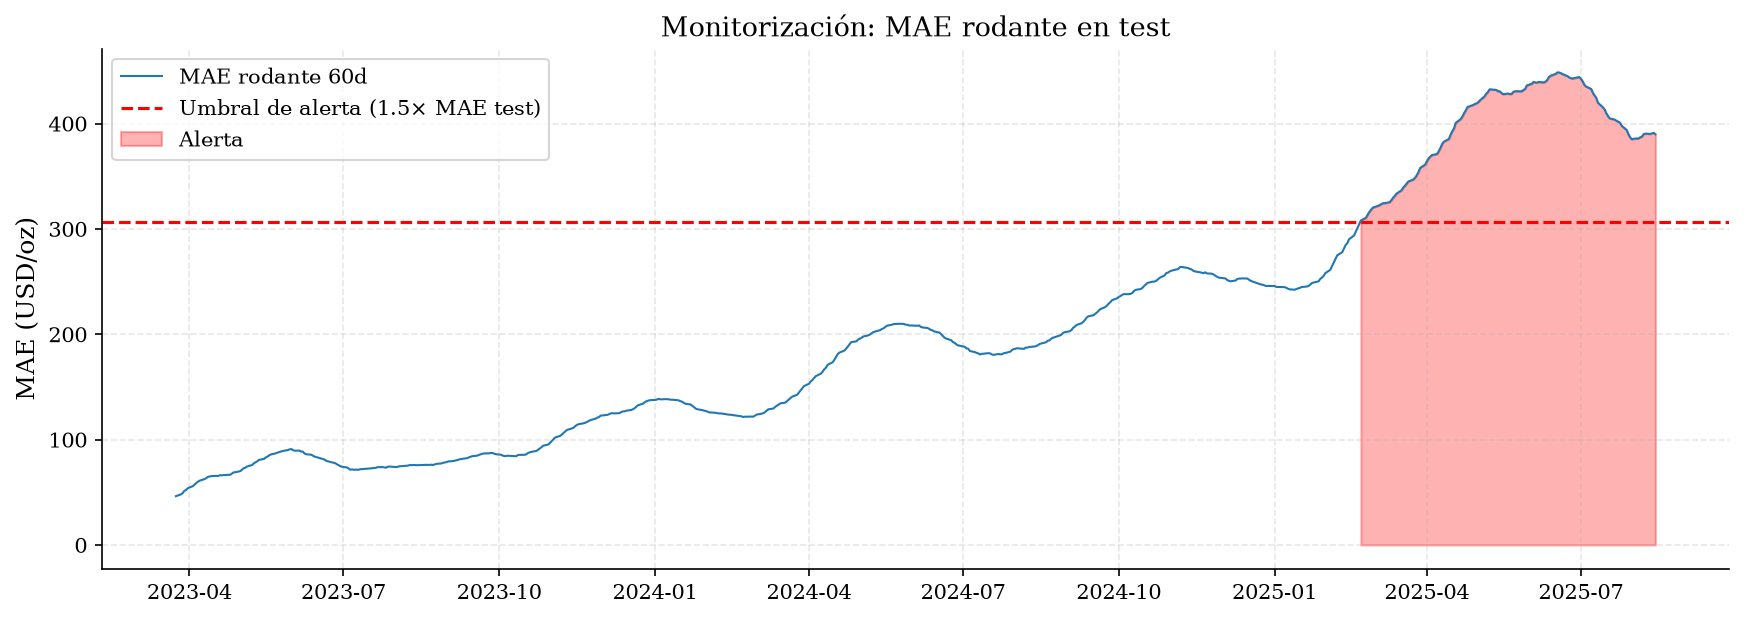

In [4]:
import matplotlib.pyplot as plt

from src.utils import set_publication_style, save_fig

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(out["date"], out["rolling_mae_60"], lw=1, label="MAE rodante 60d")
ax.axhline(1.5 * np.nanmean(out["abs_err"]), color="red", ls="--",
           label="Umbral de alerta (1.5× MAE test)")
ax.fill_between(out["date"], 0, out["rolling_mae_60"],
                where=out["alarm"], color="red", alpha=0.3, label="Alerta")
ax.set_title("Monitorización: MAE rodante en test")
ax.set_ylabel("MAE (USD/oz)")
ax.legend()
save_fig(fig, "monitoring_rolling_mae.png")

23.2/23.4 Drift de features y criterio de reentrenamiento.

Comprobación rápida de drift (KS) en una muestra de features y resumen
del criterio de reentrenamiento. El script `scripts/monitor_drift.py`
automatiza esto en producción.

In [5]:
from scipy.stats import ks_2samp

train_val = pd.concat([parts["train"], parts["val"]]).sort_values("date").reset_index(drop=True)
drift_flags = []
for c in sel_cols[:10]:
    p = ks_2samp(train_val[c].dropna(), te[c].dropna()).pvalue
    drift_flags.append((c, p < 0.01))
n_drift = sum(f for _, f in drift_flags)
print(f"Features con drift significativo (KS p<0.01) en muestra: {n_drift}/10")

print("""
Criterios de reentrenamiento (fase 23.4):
1. MAE rodante (60d) > 1.5× MAE de test durante > 20 días hábiles.
2. Drift significativo (KS p<0.01) en > 30% de las features.
3. Nuevos datos acumulados: +250 días hábiles desde el último entrenamiento.

Proceso: nuevo split -> re-tune opcional -> comparación vs modelo actual en
ventana reciente -> aprobación -> versionado (models/vX) -> rollback posible.
""")

Features con drift significativo (KS p<0.01) en muestra: 10/10

Criterios de reentrenamiento (fase 23.4):
1. MAE rodante (60d) > 1.5× MAE de test durante > 20 días hábiles.
2. Drift significativo (KS p<0.01) en > 30% de las features.
3. Nuevos datos acumulados: +250 días hábiles desde el último entrenamiento.

Proceso: nuevo split -> re-tune opcional -> comparación vs modelo actual en
ventana reciente -> aprobación -> versionado (models/vX) -> rollback posible.

